In [1]:
import copy
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, FormatStrFormatter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.grid": False,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10,
    #"legend.facecolor": 'inherit',
    "lines.linewidth": 2.0,
    "ytick.right": True,
    "xtick.top": True,
    "ytick.direction": 'in',
    "xtick.direction": 'in',
    "font.serif": 'Times New Roman',
    "font.family": 'serif',
    "xtick.minor.visible": True,
    "ytick.minor.size": 5.0,
    "ytick.major.size": 2.0,
})

#plt.rcParams.keys()

band_colors = {"u": "#122896", # blue
               "g": "#5f1296", # purple
               "r": "#ff9717", # orange
               "i": "#f51b1b", # red
               "driver": "#7ea612", # green
              "support": "#cf5f9a"} # dark pink

band_markers = {"u": 'v', # triangle (down)
               "g": 'D', # diamond
               "r": 'o', # circle
               "i": 's', # square
               "highlight": 'h', } # hexagon

line_colors = {"train": "#a6085c", # pink
               "valid": "#73c5ff", # blue
               "loss": "#2f730a", # green
               "curve": "#0a2d73", # blue
              }


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print("device =", device)


device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


## 1. OU/DRW driver and multiband transfer functions

Simulate a latent driver \(x(t)\) as an OU/DRW process:

$$
dx = -\frac{1}{\tau}(x-\mu)dt + \sigma \sqrt{dt}\,\epsilon_t.
$$

A Wiener process behaves like: $dW_t \sim \sqrt{dt}$

Each observed band is generated by convolving the driver with a causal transfer function:

$$
y_b(t) = A_b \int x(t-\Delta)\,\Psi_b(\Delta)\,d\Delta + \eta_b(t).
$$

Here we use a normalized Gaussian transfer function with band-dependent centroid and width.



In [4]:
def simulate_ou_driver(
    t: np.ndarray,
    tau: float = 25.0,
    sigma: float = 0.25,
    mu: float = 0.0,
    x0: float = 0.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    x = np.zeros_like(t, dtype=np.float32)
    x[0] = x0
    for i in range(1, len(t)):
        dt = float(t[i] - t[i - 1])
        phi = math.exp(-dt / tau)
        var = sigma**2 * tau / 2.0 * (1.0 - math.exp(-2.0 * dt / tau))
        x[i] = mu + (x[i - 1] - mu) * phi + rng.normal(0.0, math.sqrt(max(var, 1e-10)))
    return x



def gaussian_transfer_kernel(
    lags: np.ndarray,
    center: float,
    width: float,
) -> np.ndarray:
    kern = np.exp(-0.5 * ((lags - center) / max(width, 1e-6)) ** 2)
    kern = np.where(lags >= 0.0, kern, 0.0)
    s = kern.sum()
    if s <= 0:
        kern = np.zeros_like(lags)
        kern[np.argmin(np.abs(lags - max(center, 0.0)))] = 1.0
        s = kern.sum()
    return kern / s


def convolve_driver_with_transfer(
    t: np.ndarray,
    driver: np.ndarray,
    center: float,
    width: float,
    amplitude: float = 1.0,
) -> np.ndarray:
    dt = float(np.median(np.diff(t)))
    max_lag = max(center + 4.0 * width, 5.0 * dt)
    lags = np.arange(0.0, max_lag + dt, dt, dtype=np.float32)
    kern = gaussian_transfer_kernel(lags, center=center, width=width)
    # causal discrete convolution
    y = np.convolve(driver, kern, mode="full")[: len(driver)]
    return (amplitude * y).astype(np.float32)


def make_multiband_dense_curves(
    n_bands: int = 4,
    t_max: float = 220.0,
    dt: float = 0.5,
    rng: np.random.Generator | None = None,
) -> Dict:
    if rng is None:
        rng = np.random.default_rng()
    t = np.arange(0.0, t_max + dt, dt, dtype=np.float32)

    tau = float(rng.uniform(18.0, 45.0))
    sigma = float(rng.uniform(0.15, 0.35))
    driver = simulate_ou_driver(t, tau=tau, sigma=sigma, rng=rng)

    band_names = ["u", "g", "r", "i"][:n_bands]
    centers = np.linspace(0.5, 6.0, n_bands) + rng.normal(0.0, 0.35, n_bands)
    widths = np.linspace(0.7, 2.0, n_bands) + rng.normal(0.0, 0.15, n_bands)
    amps = np.linspace(0.8, 1.3, n_bands) + rng.normal(0.0, 0.06, n_bands)

    bands = {}
    for b, name in enumerate(band_names):
        y_clean = convolve_driver_with_transfer(
            t,
            driver,
            center=float(max(0.1, centers[b])),
            width=float(max(0.15, widths[b])),
            amplitude=float(max(0.2, amps[b])),
        )
        # weak band-specific extra roughness
        extra = simulate_ou_driver(
            t,
            tau=float(rng.uniform(8.0, 20.0)),
            sigma=float(rng.uniform(0.01, 0.05)),
            rng=rng,
        )
        y = (y_clean + 0.15 * extra).astype(np.float32)
        bands[name] = {
            "y_dense": y,
            "center": float(max(0.1, centers[b])),
            "width": float(max(0.15, widths[b])),
            "amp": float(max(0.2, amps[b])),
        }

    return {
        "t_dense": t,
        "driver_dense": driver.astype(np.float32),
        "bands": bands,
        "driver_tau": tau,
        "driver_sigma": sigma,
    }


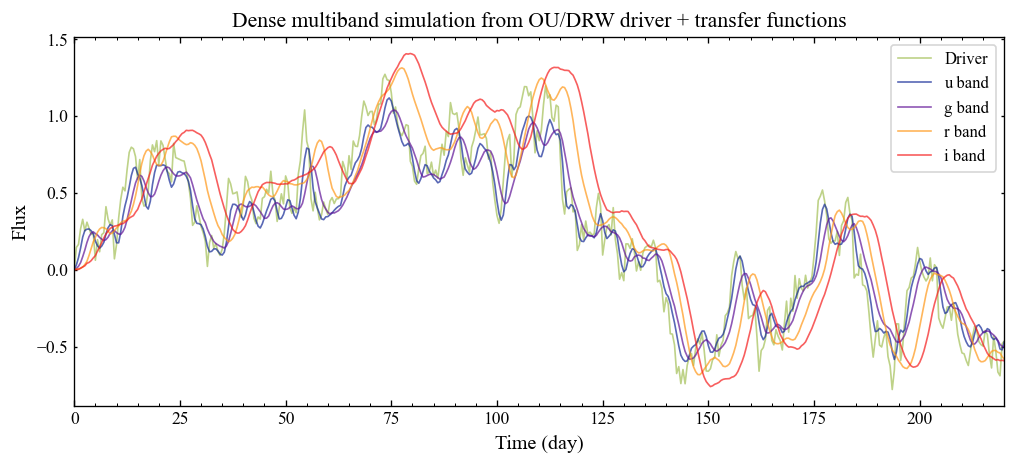

u {'center': 0.602, 'width': 0.631, 'amp': 0.881}
g {'center': 1.782, 'width': 1.192, 'amp': 0.874}
r {'center': 3.642, 'width': 1.401, 'amp': 1.148}
i {'center': 5.999, 'width': 2.158, 'amp': 1.283}


In [5]:
rng = np.random.default_rng(123)
demo = make_multiband_dense_curves(n_bands=4, rng=rng)

plt.figure(figsize=(10, 4))
plt.plot(demo["t_dense"], demo["driver_dense"], label="Driver", 
         alpha = 0.5, lw = 1, color = band_colors["driver"])
for band, info in demo["bands"].items():
    plt.plot(demo["t_dense"], info["y_dense"], label=f"{band} band",
             alpha = 0.7, lw = 1, color = band_colors[band])

plt.xlim(demo["t_dense"][0], demo["t_dense"][-1])
plt.xlabel("Time (day)")
plt.ylabel("Flux")
plt.title("Dense multiband simulation from OU/DRW driver + transfer functions")
plt.legend()
plt.show()

for band, info in demo["bands"].items():
    print(band, {k: round(v, 3) for k, v in info.items() if k != "y_dense"})


## Sparse sampling and target-gap construction

Dense multiband curves are converted into irregular sparse observations by randomly subsampling each band and adding heteroscedastic observational noise. A target band is then selected, and a large cadence gap is identified within its sparse observations. The target band is forced to contain no observations inside this interval, while auxiliary bands may retain observations within the same temporal window.


## 2.0 Sparse sampling

In [6]:
def make_sparse_band_observations(
    t_dense: np.ndarray,
    y_dense: np.ndarray,
    n_obs_range: Tuple[int, int] = (34, 70),
    noise_range: Tuple[float, float] = (0.02, 0.06),
    rng: np.random.Generator | None = None,
) -> Dict[str, np.ndarray]:

    if rng is None:
        rng = np.random.default_rng()

    n_obs = int(rng.integers(n_obs_range[0], n_obs_range[1] + 1))

    idx = np.sort(
        rng.choice(
            len(t_dense),
            size=n_obs,
            replace=False,
        )
    )

    t_obs = t_dense[idx]
    y_true = y_dense[idx]

    yerr = rng.uniform(
        noise_range[0],
        noise_range[1],
        size=n_obs,
    ).astype(np.float32)

    y_obs = (
        y_true + rng.normal(0.0, yerr)
    ).astype(np.float32)

    return {
        "t_obs": t_obs.astype(np.float32),
        "y_obs": y_obs.astype(np.float32),
        "yerr_obs": yerr.astype(np.float32),
        "idx_obs": idx.astype(np.int64),
    }

## 3.0 Gap Checks

In [7]:
def count_aux_points_in_gap(
    sparse: Dict[str, Dict[str, np.ndarray]],
    target_band: str,
    t_left: float,
    t_right: float,
) -> Tuple[int, int, Dict[str, int]]:

    total = 0
    bands_with_point = 0
    per_band = {}

    for band, obs in sparse.items():

        if band == target_band:
            continue

        t_obs = obs["t_obs"]

        count = int(
            np.sum(
                (t_obs > t_left)
                & (t_obs < t_right)
            )
        )

        per_band[band] = count
        total += count

        if count > 0:
            bands_with_point += 1

    return total, bands_with_point, per_band

In [8]:
def list_valid_target_gaps(
    sparse: Dict[str, Dict[str, np.ndarray]],
    target_band: str,
    min_gap: float = 5.0,
    quantile: float = 0.80,
    min_aux_points_in_gap: int = 1,
) -> List[Dict]:

    target = sparse[target_band]
    t_obs = target["t_obs"]

    if len(t_obs) < 2:
        return []

    dt = np.diff(t_obs)
    threshold = max(min_gap, float(np.quantile(dt, quantile)))

    candidates = np.where(dt >= threshold)[0]

    if len(candidates) == 0:
        candidates = np.array([int(np.argmax(dt))])

    valid = []

    for left_idx in candidates:

        right_idx = int(left_idx + 1)

        t_left = float(t_obs[left_idx])
        t_right = float(t_obs[right_idx])
        gap_width = t_right - t_left

        aux_total, aux_bands, aux_per_band = count_aux_points_in_gap(
            sparse=sparse,
            target_band=target_band,
            t_left=t_left,
            t_right=t_right,
        )

        target_points = int(
            np.sum(
                (t_obs > t_left)
                & (t_obs < t_right)
            )
        )

        if aux_total >= min_aux_points_in_gap and target_points == 0:
            valid.append({
                "left_idx": int(left_idx),
                "right_idx": int(right_idx),
                "t_left": t_left,
                "t_right": t_right,
                "gap_width": float(gap_width),
                "aux_points_in_gap": int(aux_total),
                "aux_bands_with_point": int(aux_bands),
                "aux_points_per_band": aux_per_band,
                "target_points_in_gap": int(target_points),
            })

    valid = sorted(
        valid,
        key=lambda d: (
            d["aux_points_in_gap"],
            d["aux_bands_with_point"],
            d["gap_width"],
        ),
        reverse=True,
    )

    return valid

## 4.0 Chose a valid example

In [9]:
def construct_example_from_multiband(
    dense: Dict,
    sparse: Dict[str, Dict[str, np.ndarray]],
    target_band: str = "r",
    K: int = 24,
    n_side: int = 6,
    require_aux_in_gap: bool = True,
    min_aux_points_in_gap: int = 1,
    fixed_gap_pair: tuple[int, int] | None = None,
) -> Dict:

    t_dense = dense["t_dense"]
    y_dense_target = dense["bands"][target_band]["y_dense"]

    target = sparse[target_band]

    if fixed_gap_pair is not None:

        left_idx, right_idx = fixed_gap_pair

    else:

        valid_gaps = list_valid_target_gaps(
            sparse=sparse,
            target_band=target_band,
            min_aux_points_in_gap=min_aux_points_in_gap,
        )

        if len(valid_gaps) == 0:

            if require_aux_in_gap:
                raise ValueError(
                    f"No valid target-band gap with at least "
                    f"{min_aux_points_in_gap} auxiliary point(s)."
                )

            dt = np.diff(target["t_obs"])
            left_idx = int(np.argmax(dt))
            right_idx = left_idx + 1

        else:
            gap = valid_gaps[0]
            left_idx = gap["left_idx"]
            right_idx = gap["right_idx"]

    t_left = float(target["t_obs"][left_idx])
    t_right = float(target["t_obs"][right_idx])
    dt_gap = t_right - t_left

    target_points_in_gap = int(
        np.sum(
            (target["t_obs"] > t_left)
            & (target["t_obs"] < t_right)
        )
    )

    aux_points_in_gap, aux_bands_with_point, aux_points_per_band = count_aux_points_in_gap(
        sparse=sparse,
        target_band=target_band,
        t_left=t_left,
        t_right=t_right,
    )

    if target_points_in_gap != 0:
        raise ValueError("Target band is not empty inside the selected gap.")

    if require_aux_in_gap and aux_points_in_gap < min_aux_points_in_gap:
        raise ValueError("Selected gap does not have required auxiliary support.")

    s_grid = np.linspace(
        0.0,
        1.0,
        K + 2,
        dtype=np.float32,
    )[1:-1]

    t_gap = (
        t_left + s_grid * dt_gap
    ).astype(np.float32)

    y_true_gap = np.interp(
        t_gap,
        t_dense,
        y_dense_target,
    ).astype(np.float32)

    side_slice_left = slice(
        max(0, left_idx - n_side + 1),
        left_idx + 1,
    )

    side_slice_right = slice(
        right_idx,
        min(len(target["y_obs"]), right_idx + n_side),
    )

    local_vals = np.concatenate([
        target["y_obs"][side_slice_left],
        target["y_obs"][side_slice_right],
    ])

    mu_local = float(np.mean(local_vals))
    amp_local = float(np.std(local_vals) + 1e-3)

    y_left = float(target["y_obs"][left_idx])
    y_right = float(target["y_obs"][right_idx])

    baseline = (
        (1.0 - s_grid) * y_left
        + s_grid * y_right
    )

    baseline_std = (
        (baseline - mu_local) / amp_local
    ).astype(np.float32)

    y_true_std = (
        (y_true_gap - mu_local) / amp_local
    ).astype(np.float32)

    residual_true_std = (
        y_true_std - baseline_std
    ).astype(np.float32)

    band_names = list(sparse.keys())
    token_rows = []
    band_id_rows = []

    token_aux_info = {}

    for b_idx, band in enumerate(band_names):

        band_obs = sparse[band]

        t_obs = band_obs["t_obs"]
        y_obs = band_obs["y_obs"]
        yerr = band_obs["yerr_obs"]

        left_mask = t_obs <= t_left
        right_mask = t_obs >= t_right
        gap_mask = (t_obs > t_left) & (t_obs < t_right)

        left_take = np.where(left_mask)[0][-n_side:]
        right_take = np.where(right_mask)[0][:n_side]
        gap_take = np.where(gap_mask)[0]

        take = np.concatenate([
            left_take,
            gap_take,
            right_take,
        ])

        if len(take) == 0:
            take = np.array([
                np.argmin(np.abs(t_obs - t_left))
            ])

        t_sel = t_obs[take]
        y_sel = y_obs[take]
        e_sel = yerr[take]

        dt_local = np.diff(t_sel)
        dy_local = np.diff(y_sel)

        slope = (
            np.median(dy_local / np.maximum(dt_local, 1e-3))
            if len(dt_local) > 0
            else 0.0
        )

        diff_std = (
            np.std(dy_local)
            if len(dy_local) > 0
            else 0.0
        )

        cad_med = (
            np.median(dt_local)
            if len(dt_local) > 0
            else dt_gap
        )

        gap_count_band = int(np.sum(gap_mask))

        feats = np.array([
            (np.mean(y_sel) - mu_local) / amp_local,
            np.std(y_sel) / amp_local,
            slope * dt_gap / amp_local,
            diff_std / amp_local,
            np.mean(e_sel) / amp_local,
            np.mean((t_sel - t_left) / max(dt_gap, 1e-3)),
            np.mean((t_sel - t_right) / max(dt_gap, 1e-3)),
            cad_med / max(dt_gap, 1e-3),
            float(np.mean(t_sel <= t_left)),
            float(np.mean(t_sel >= t_right)),
            float(gap_count_band),
            float(gap_count_band > 0),
            dense["bands"][band]["center"] / max(dt_gap, 1e-3),
            dense["bands"][band]["width"] / max(dt_gap, 1e-3),
            dense["bands"][band]["amp"],
        ], dtype=np.float32)

        token_rows.append(feats)
        band_id_rows.append(b_idx)

        token_aux_info[band] = {
            "n_left_context": int(len(left_take)),
            "n_right_context": int(len(right_take)),
            "n_gap_context": int(len(gap_take)),
            "selected_indices": take.astype(np.int64),
            "selected_times": t_sel.astype(np.float32),
        }

    context_tokens = np.stack(
        token_rows,
        axis=0,
    ).astype(np.float32)

    band_ids = np.array(
        band_id_rows,
        dtype=np.int64,
    )

    return {
        "target_band": target_band,
        "band_names": band_names,
        "context_tokens": context_tokens,
        "band_ids": band_ids,
        "y_true_gap": y_true_gap,
        "y_true_std": y_true_std,
        "baseline_std": baseline_std,
        "residual_true_std": residual_true_std,
        "mu_local": np.float32(mu_local),
        "amp_local": np.float32(amp_local),
        "t_left": np.float32(t_left),
        "t_right": np.float32(t_right),
        "t_gap": t_gap,
        "dt_gap": np.float32(dt_gap),
        "gap_left_idx": int(left_idx),
        "gap_right_idx": int(right_idx),
        "gap_pair": (int(left_idx), int(right_idx)),
        "target_sparse": target,
        "dense": dense,
        "sparse_demo": sparse,
        "target_points_in_gap": int(target_points_in_gap),
        "aux_points_in_gap": int(aux_points_in_gap),
        "aux_bands_with_point": int(aux_bands_with_point),
        "aux_points_per_band": aux_points_per_band,
        "token_aux_info": token_aux_info,
    }

## 5.0 Sampler

In [10]:
def sample_supported_example(
    n_bands: int = 4,
    K: int = 24,
    n_side: int = 6,
    target_band: str | None = None,
    rng: np.random.Generator | None = None,
    max_tries: int = 250,
) -> Dict:

    if rng is None:
        rng = np.random.default_rng()

    band_names = ["u", "g", "r", "i"][:n_bands]

    for _ in range(max_tries):

        dense = make_multiband_dense_curves(
            n_bands=n_bands,
            rng=rng,
        )

        sparse = {
            band: make_sparse_band_observations(
                dense["t_dense"],
                dense["bands"][band]["y_dense"],
                rng=rng,
            )
            for band in band_names
        }

        chosen_target = (
            target_band
            if target_band is not None
            else rng.choice(band_names)
        )

        try:
            ex = construct_example_from_multiband(
                dense=dense,
                sparse=sparse,
                target_band=chosen_target,
                K=K,
                n_side=n_side,
                require_aux_in_gap=True,
                min_aux_points_in_gap=1,
            )

            return ex

        except ValueError:
            continue

    raise RuntimeError(
        "Could not generate a valid multiband example."
    )

## 6. Rebuild example after support

In [11]:
def enforce_aux_support_on_sparse(
    sparse: Dict[str, Dict[str, np.ndarray]],
    target_band: str,
    t_left: float,
    t_right: float,
    n_aux_points: int,
    n_aux_bands: int,
    rng: np.random.Generator | None = None,
) -> Dict[str, Dict[str, np.ndarray]]:

    if rng is None:
        rng = np.random.default_rng()

    sparse_new = copy.deepcopy(sparse)

    aux_bands = [
        b for b in sparse_new.keys()
        if b != target_band
    ]

    available = {}

    for band in aux_bands:

        t_obs = sparse_new[band]["t_obs"]

        available[band] = int(
            np.sum(
                (t_obs > t_left)
                & (t_obs < t_right)
            )
        )

    usable_bands = [
        b for b in aux_bands
        if available[b] > 0
    ]

    if n_aux_points == 0:
        n_aux_bands = 0

    if n_aux_bands > len(usable_bands):
        raise ValueError("Not enough usable auxiliary bands.")

    if n_aux_points > sum(available.values()):
        raise ValueError("Not enough auxiliary points available.")

    if n_aux_points < n_aux_bands:
        raise ValueError("Need at least one point per auxiliary band.")

    if n_aux_bands == 0:
        chosen_bands = []
    else:
        chosen_bands = rng.choice(
            usable_bands,
            size=n_aux_bands,
            replace=False,
        ).tolist()

    keep_counts = {b: 0 for b in aux_bands}

    for band in chosen_bands:
        keep_counts[band] = 1

    remaining = n_aux_points - n_aux_bands

    for _ in range(remaining):

        candidates = [
            b for b in chosen_bands
            if keep_counts[b] < available[b]
        ]

        if len(candidates) == 0:
            raise ValueError("Could not allocate remaining support.")

        chosen = rng.choice(candidates)
        keep_counts[chosen] += 1

    for band in aux_bands:

        obs = sparse_new[band]

        t_obs = obs["t_obs"]
        y_obs = obs["y_obs"]
        yerr_obs = obs["yerr_obs"]
        idx_obs = obs["idx_obs"]

        in_gap = (
            (t_obs > t_left)
            & (t_obs < t_right)
        )

        in_idx = np.where(in_gap)[0]
        out_idx = np.where(~in_gap)[0]

        want = keep_counts[band]

        if want == 0:
            keep_idx = out_idx
        else:
            chosen_local = rng.choice(
                len(in_idx),
                size=want,
                replace=False,
            )

            chosen_idx = in_idx[np.sort(chosen_local)]

            keep_idx = np.sort(
                np.concatenate([
                    out_idx,
                    chosen_idx,
                ])
            )

        sparse_new[band]["t_obs"] = t_obs[keep_idx]
        sparse_new[band]["y_obs"] = y_obs[keep_idx]
        sparse_new[band]["yerr_obs"] = yerr_obs[keep_idx]
        sparse_new[band]["idx_obs"] = idx_obs[keep_idx]

    target = sparse_new[target_band]
    target_t = target["t_obs"]

    keep_target = ~(
        (target_t > t_left)
        & (target_t < t_right)
    )

    for key in ["t_obs", "y_obs", "yerr_obs", "idx_obs"]:
        sparse_new[target_band][key] = target[key][keep_target]

    return sparse_new

## Rebuilding examples after auxiliary-support modification

The controlled-support experiments modify the auxiliary observations inside the target-band gap by selectively removing or retaining support points. Because the model conditioning depends directly on the sparse observational configuration, the example must be fully reconstructed after these modifications are applied.

The function `rebuild_example_with_controlled_support` first updates the sparse auxiliary observations through `enforce_aux_support_on_sparse`, and then calls `construct_example_from_multiband` to recompute all derived representations from the modified sparse data. This includes `context_tokens`, `baseline_std`, `y_true_std`, `residual_true_std`, and all support-related metadata.

This rebuilding step is essential for the validity of the support-control analysis. Reusing previously computed context quantities after altering the auxiliary observations would leave stale conditioning information inside the example representation and produce inconsistent model inputs.

In [12]:
def rebuild_example_with_controlled_support(
    ex_base: Dict,
    n_aux_points: int,
    n_aux_bands: int,
    rng: np.random.Generator | None = None,
) -> Dict:

    if rng is None:
        rng = np.random.default_rng()

    sparse_new = enforce_aux_support_on_sparse(
        sparse=ex_base["sparse_demo"],
        target_band=ex_base["target_band"],
        t_left=float(ex_base["t_left"]),
        t_right=float(ex_base["t_right"]),
        n_aux_points=n_aux_points,
        n_aux_bands=n_aux_bands,
        rng=rng,
    )

    ex_new = construct_example_from_multiband(
        dense=ex_base["dense"],
        sparse=sparse_new,
        target_band=ex_base["target_band"],
        K=len(ex_base["t_gap"]),
        n_side=6,
        require_aux_in_gap=False,
        fixed_gap_pair=ex_base["gap_pair"],
    )

    ex_new["requested_aux_points_in_gap"] = int(n_aux_points)
    ex_new["requested_aux_bands_with_point"] = int(n_aux_bands)

    return ex_new

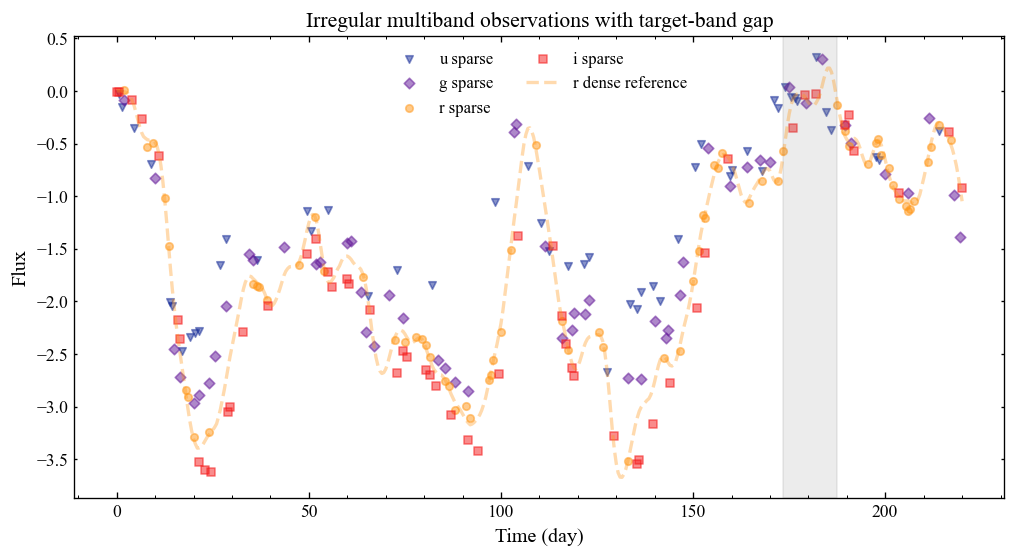

target band: r
gap width: 14.0
aux points: 13
aux bands: 3
aux per band: {'u': 7, 'g': 3, 'i': 3}
context shape: (4, 15)
residual shape: (24,)


In [13]:
rng = np.random.default_rng(7)

example = sample_supported_example(
    n_bands=4,
    K=24,
    n_side=6,
    target_band="r",
    rng=rng,
)

plt.figure(figsize=(10, 5))

for band, obs in example["sparse_demo"].items():

    plt.scatter(
        obs["t_obs"],
        obs["y_obs"],
        s=20,
        color=band_colors[band],
        marker=band_markers[band],
        alpha=0.5,
        label=f"{band} sparse",
    )

plt.axvspan(
    float(example["t_left"]),
    float(example["t_right"]),
    color="grey",
    alpha=0.15,
)

plt.plot(
    example["dense"]["t_dense"],
    example["dense"]["bands"][example["target_band"]]["y_dense"],
    color=band_colors[example["target_band"]],
    alpha=0.35,
    ls="--",
    label=f"{example['target_band']} dense reference",
)

plt.title("Irregular multiband observations with target-band gap")
plt.xlabel("Time (day)")
plt.ylabel("Flux")
plt.legend(ncol=2, frameon=False)
plt.show()

print("target band:", example["target_band"])
print("gap width:", float(example["dt_gap"]))
print("aux points:", example["aux_points_in_gap"])
print("aux bands:", example["aux_bands_with_point"])
print("aux per band:", example["aux_points_per_band"])
print("context shape:", example["context_tokens"].shape)
print("residual shape:", example["residual_true_std"].shape)

## 7. Dataset

In [14]:
class MultibandGapDataset(Dataset):
    def __init__(
        self,
        n_examples: int = 2500,
        n_bands: int = 4,
        K: int = 24,
        n_side: int = 6,
        target_band_choices: List[str] | None = None,
        seed: int = 123,
        max_tries_per_example: int = 250,
    ):
        self.examples = []

        rng = np.random.default_rng(seed)

        band_names = ["u", "g", "r", "i"][:n_bands]

        if target_band_choices is None:
            target_band_choices = band_names.copy()

        while len(self.examples) < n_examples:

            chosen_target = rng.choice(target_band_choices)

            try:
                ex = sample_supported_example(
                    n_bands=n_bands,
                    K=K,
                    n_side=n_side,
                    target_band=chosen_target,
                    rng=rng,
                    max_tries=max_tries_per_example,
                )

                self.examples.append(ex)

            except RuntimeError:
                continue

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx: int):

        ex = self.examples[idx]

        return {
            "context_tokens": torch.tensor(ex["context_tokens"], dtype=torch.float32),
            "band_ids": torch.tensor(ex["band_ids"], dtype=torch.long),
            "residual_true_std": torch.tensor(ex["residual_true_std"], dtype=torch.float32),
            "baseline_std": torch.tensor(ex["baseline_std"], dtype=torch.float32),
            "y_true_std": torch.tensor(ex["y_true_std"], dtype=torch.float32),
            "dt_gap": torch.tensor(ex["dt_gap"], dtype=torch.float32),
            "aux_points_in_gap": torch.tensor(ex["aux_points_in_gap"], dtype=torch.long),
            "aux_bands_with_point": torch.tensor(ex["aux_bands_with_point"], dtype=torch.long),
        }

## Examples


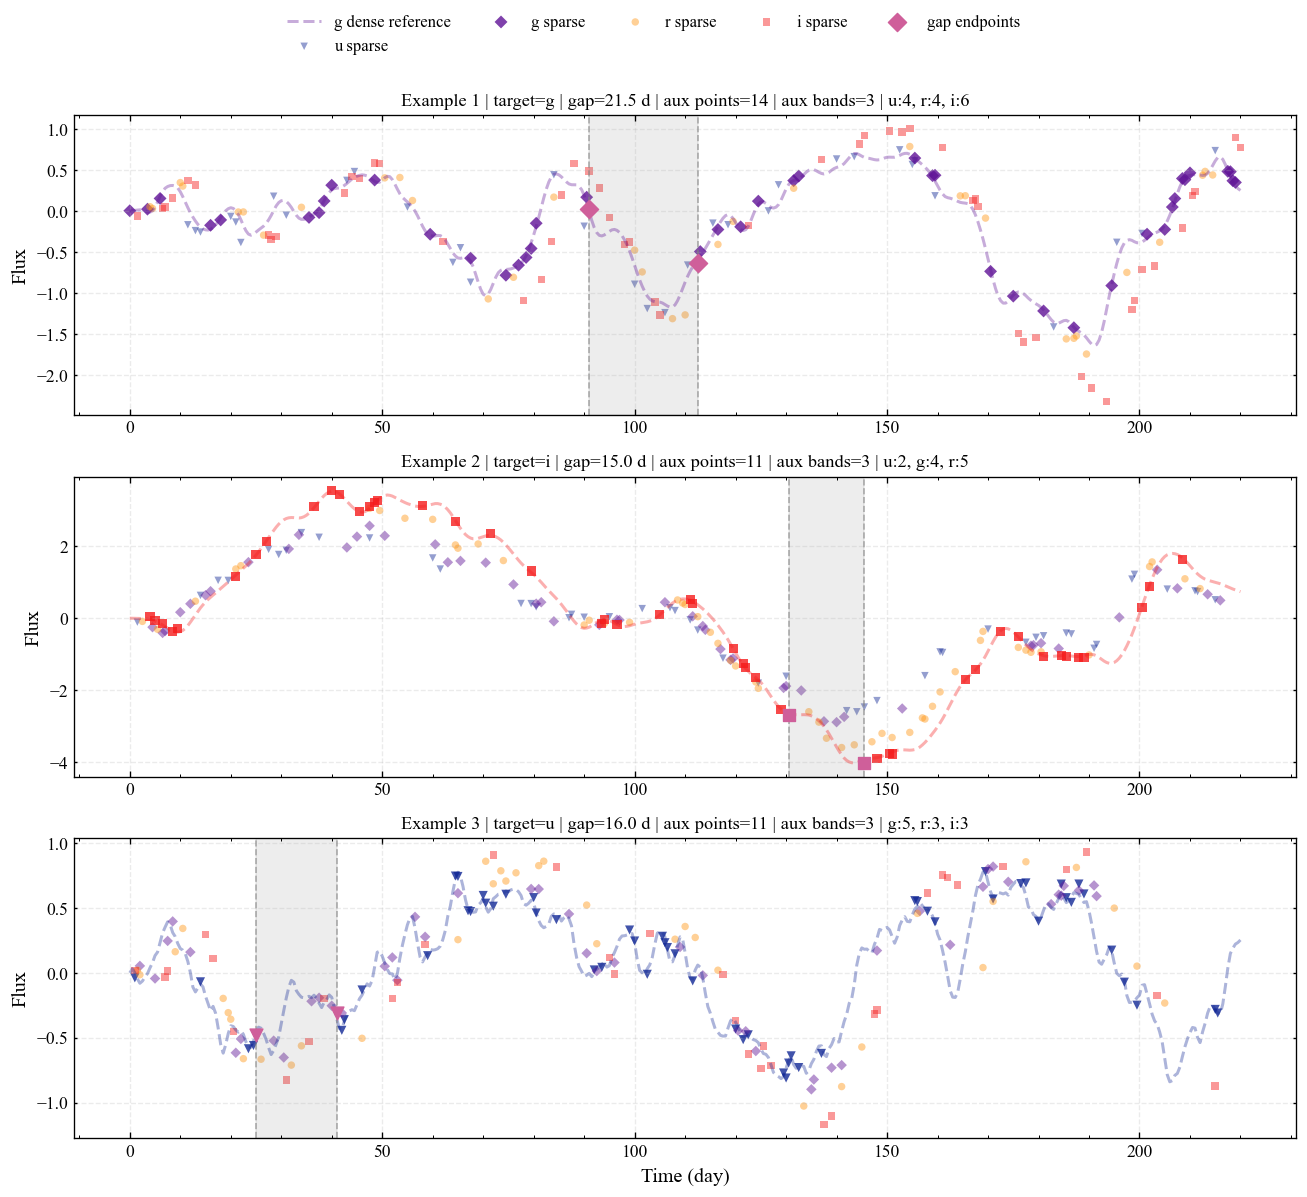

In [15]:
rng = np.random.default_rng(2024)

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 10),
    sharex=False,
)

for i, ax in enumerate(axes):

    ex = sample_supported_example(
        n_bands=4,
        K=24,
        n_side=6,
        target_band=None,
        rng=rng,
    )

    target_band = ex["target_band"]
    t_left = float(ex["t_left"])
    t_right = float(ex["t_right"])

    # Dense reference
    ax.plot(
        ex["dense"]["t_dense"],
        ex["dense"]["bands"][target_band]["y_dense"],
        color=band_colors[target_band],
        lw=1.8,
        alpha=0.35,
        ls="--",
        label=f"{target_band} dense reference",
    )

    # sparse observations
    for band, obs in ex["sparse_demo"].items():

        is_target = band == target_band

        ax.scatter(
            obs["t_obs"],
            obs["y_obs"],
            s=30 if is_target else 20,
            color=band_colors[band],
            marker=band_markers[band],
            alpha=0.8 if is_target else 0.45,
            label=f"{band} sparse",
            edgecolor="none",
        )

    # Gap shading
    ax.axvspan(
        t_left,
        t_right,
        color="grey",
        alpha=0.14,
    )

    ax.axvline(
        t_left,
        color="grey",
        ls="--",
        lw=1,
        alpha=0.6,
    )

    ax.axvline(
        t_right,
        color="grey",
        ls="--",
        lw=1,
        alpha=0.6,
    )

    # Gap endpoints
    y_left = float(ex["target_sparse"]["y_obs"][ex["gap_left_idx"]])
    y_right = float(ex["target_sparse"]["y_obs"][ex["gap_right_idx"]])

    ax.scatter(
        [t_left, t_right],
        [y_left, y_right],
        s=60,
        color=band_colors["support"],
        marker=band_markers[target_band],
        #edgecolor="black",
        linewidth=0.8,
        zorder=10,
        label="gap endpoints",
    )

    aux_per_band = ", ".join(
        [f"{b}:{c}" for b, c in ex["aux_points_per_band"].items()]
    )

    ax.set_title(
        f"Example {i+1} | target={target_band} | "
        f"gap={float(ex['dt_gap']):.1f} d | "
        f"aux points={ex['aux_points_in_gap']} | "
        f"aux bands={ex['aux_bands_with_point']} | "
        f"{aux_per_band}",
        fontsize=11,
    )

    ax.set_ylabel("Flux")
    ax.grid(alpha=0.25, linestyle="--")

axes[-1].set_xlabel("Time (day)")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=5,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [16]:
train_ds = MultibandGapDataset(n_examples=2200, seed=100)
val_ds = MultibandGapDataset(n_examples=350, seed=200)

batch_size = 96
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

first = next(iter(train_loader))
for k, v in first.items():
    print(k, tuple(v.shape))

context_tokens (96, 4, 15)
band_ids (96, 4)
residual_true_std (96, 24)
baseline_std (96, 24)
y_true_std (96, 24)
dt_gap (96,)
aux_points_in_gap (96,)
aux_bands_with_point (96,)


## Conditional flow reconstruction model

The reconstruction model is implemented as a conditional RealNVP normalizing flow. The flow learns a conditional probability distribution over the hidden residual trajectory inside the target gap. Conditioning information is provided through multiband context tokens that summarize local observational statistics for each band, including variability, cadence, relative timing, and auxiliary support information.

The model predicts a distribution of possible reconstructions rather than a single deterministic estimate, allowing uncertainty intervals to be estimated directly from posterior samples.

## 8. Flow Model 

In [17]:

class ContextEncoder(nn.Module):
    def __init__(self, token_dim: int, n_bands: int, context_dim: int = 128, hidden: int = 128):
        super().__init__()
        self.band_emb = nn.Embedding(n_bands, 16)
        self.token_mlp = nn.Sequential(
            nn.Linear(token_dim + 16, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, context_dim),
        )

    def forward(self, tokens: torch.Tensor, band_ids: torch.Tensor) -> torch.Tensor:
        # tokens: [B, n_bands, token_dim]
        emb = self.band_emb(band_ids)  # [B, n_bands, 16]
        x = torch.cat([tokens, emb], dim=-1)
        h = self.token_mlp(x)
        pooled = h.mean(dim=1)
        return self.out(pooled)


class CouplingMLP(nn.Module):
    def __init__(self, in_dim: int, context_dim: int, hidden: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + context_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        c = context.expand(x.shape[0], -1)
        return self.net(torch.cat([x, c], dim=-1))


class ConditionalAffineCoupling(nn.Module):
    def __init__(self, dim: int, mask: torch.Tensor, context_dim: int, hidden: int = 128):
        super().__init__()
        self.dim = dim
        self.register_buffer("mask", mask.view(1, dim))
        in_dim = int(mask.sum().item())
        out_dim = dim - in_dim
        self.s_net = CouplingMLP(in_dim, context_dim, hidden, out_dim)
        self.t_net = CouplingMLP(in_dim, context_dim, hidden, out_dim)

    def _split(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x_id = x[:, self.mask[0].bool()]
        x_change = x[:, (~self.mask[0].bool())]
        return x_id, x_change

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x_id, x_change = self._split(x)
        log_s = torch.tanh(self.s_net(x_id, context))
        t = self.t_net(x_id, context)
        y_change = x_change * torch.exp(log_s) + t

        y = x.clone()
        y[:, (~self.mask[0].bool())] = y_change
        logdet = log_s.sum(dim=-1)
        return y, logdet

    def inverse(self, y: torch.Tensor, context: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        y_id, y_change = self._split(y)
        log_s = torch.tanh(self.s_net(y_id, context))
        t = self.t_net(y_id, context)
        x_change = (y_change - t) * torch.exp(-log_s)

        x = y.clone()
        x[:, (~self.mask[0].bool())] = x_change
        logdet = -log_s.sum(dim=-1)
        return x, logdet


class ConditionalRealNVP(nn.Module):
    def __init__(
        self,
        residual_dim: int,
        token_dim: int,
        n_bands: int,
        context_dim: int = 128,
        hidden: int = 128,
        n_layers: int = 6,
    ):
        super().__init__()
        self.residual_dim = residual_dim
        self.context_encoder = ContextEncoder(token_dim=token_dim, n_bands=n_bands, context_dim=context_dim, hidden=hidden)

        layers = []
        for i in range(n_layers):
            mask = torch.tensor([(j + i) % 2 for j in range(residual_dim)], dtype=torch.float32)
            if mask.sum() == 0 or mask.sum() == residual_dim:
                mask = torch.tensor([1 if j < residual_dim // 2 else 0 for j in range(residual_dim)], dtype=torch.float32)
            layers.append(ConditionalAffineCoupling(residual_dim, mask, context_dim=context_dim, hidden=hidden))
        self.layers = nn.ModuleList(layers)

        self.base_loc = nn.Parameter(torch.zeros(residual_dim), requires_grad=False)
        self.base_log_scale = nn.Parameter(torch.zeros(residual_dim), requires_grad=False)

    def encode_context(self, tokens: torch.Tensor, band_ids: torch.Tensor) -> torch.Tensor:
        return self.context_encoder(tokens, band_ids)

    def forward_flow(self, z: torch.Tensor, context: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = z
        total_logdet = torch.zeros(z.shape[0], device=z.device)
        for layer in self.layers:
            x, ld = layer(x, context)
            total_logdet = total_logdet + ld
        return x, total_logdet

    def inverse_flow(self, x: torch.Tensor, context: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z = x
        total_logdet = torch.zeros(x.shape[0], device=x.device)
        for layer in reversed(self.layers):
            z, ld = layer.inverse(z, context)
            total_logdet = total_logdet + ld
        return z, total_logdet

    def log_prob(self, x: torch.Tensor, tokens: torch.Tensor, band_ids: torch.Tensor) -> torch.Tensor:
        context = self.encode_context(tokens, band_ids)
        z, logdet = self.inverse_flow(x, context)
        log_base = -0.5 * (((z - self.base_loc) / torch.exp(self.base_log_scale)) ** 2 + math.log(2 * math.pi)).sum(dim=-1)
        return log_base + logdet

    def sample(self, n_samples: int, tokens: torch.Tensor, band_ids: torch.Tensor) -> torch.Tensor:
        context = self.encode_context(tokens, band_ids)
        B = context.shape[0]
        z = torch.randn(B * n_samples, self.residual_dim, device=context.device)
        context_rep = context[:, None, :].expand(B, n_samples, context.shape[-1]).reshape(B * n_samples, -1)
        x, _ = self.forward_flow(z, context_rep)
        return x.reshape(B, n_samples, self.residual_dim)


In [18]:

token_dim = train_ds[0]["context_tokens"].shape[-1]
residual_dim = train_ds[0]["residual_true_std"].shape[-1]
n_bands = train_ds[0]["context_tokens"].shape[0]

model = ConditionalRealNVP(
    residual_dim=residual_dim,
    token_dim=token_dim,
    n_bands=n_bands,
    context_dim=128,
    hidden=160,
    n_layers=8,
).to(device)

print(model.__class__.__name__)
print("parameters =", sum(p.numel() for p in model.parameters() if p.requires_grad))

ConditionalRealNVP
parameters = 881344


## Training procedure

For each example, the hidden target-band segment is represented relative to a simple linear interpolation baseline between the gap endpoints. The flow is trained to model these standardized residual trajectories.

Optimization minimizes the negative log-likelihood of the true residual sequence under the conditional flow distribution, together with a small roughness consistency term intended to encourage realistic temporal variability in generated samples.

## 9. Training Objective

In [ ]:

def compute_loss(model: ConditionalRealNVP, batch: Dict[str, torch.Tensor], sample_count: int = 6):
    tokens = batch["context_tokens"].to(device)
    band_ids = batch["band_ids"].to(device)
    residual_true = batch["residual_true_std"].to(device)
    y_true = batch["y_true_std"].to(device)
    baseline = batch["baseline_std"].to(device)

    logp = model.log_prob(residual_true, tokens, band_ids)
    nll = -logp.mean()

    # optional roughness consistency
    with torch.no_grad():
        residual_samples = model.sample(sample_count, tokens, band_ids)  # [B, S, K]
        
    pred_y = baseline[:, None, :] + residual_samples
    true_d1 = y_true[:, 1:] - y_true[:, :-1]
    pred_d1 = pred_y[:, :, 1:] - pred_y[:, :, :-1]
    pred_d1_std = pred_d1.std(dim=1).mean(dim=-1)
    true_d1_std = true_d1.std(dim=-1)
    rough = F.mse_loss(pred_d1_std, true_d1_std)

    loss = nll + 0.05 * rough
    return loss, nll.detach(), rough.detach()

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


In [21]:
def evaluate_loader(model, loader):
    model.eval()
    vals = {"loss": [], "nll": [], "rough": []}
    with torch.no_grad():
        for batch in loader:
            loss, nll, rough = compute_loss(model, batch, sample_count=6)
            vals["loss"].append(float(loss.item()))
            vals["nll"].append(float(nll.item()))
            vals["rough"].append(float(rough.item()))
    return {k: float(np.mean(v)) for k, v in vals.items()}

history = []
n_epochs = 30

for epoch in range(1, n_epochs + 1):
    model.train()
    running = {"loss": [], "nll": [], "rough": []}
    for batch in train_loader:
        loss, nll, rough = compute_loss(model, batch, sample_count=4)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        running["loss"].append(float(loss.item()))
        running["nll"].append(float(nll.item()))
        running["rough"].append(float(rough.item()))

    train_stats = {k: float(np.mean(v)) for k, v in running.items()}
    val_stats = evaluate_loader(model, val_loader)
    history.append({"epoch": epoch, **{f"train_{k}": v for k, v in train_stats.items()},
                    **{f"val_{k}": v for k, v in val_stats.items()}})
    print(f"epoch {epoch:02d} | train loss {train_stats['loss']:.4f} | val loss {val_stats['loss']:.4f} | val nll {val_stats['nll']:.4f}")


epoch 01 | train loss 19.2673 | val loss 18.0474 | val nll 18.0419
epoch 02 | train loss 4.6124 | val loss -3.1480 | val nll -3.1494
epoch 03 | train loss -5.8498 | val loss -4.6564 | val nll -4.6573
epoch 04 | train loss -8.1490 | val loss -10.6782 | val nll -10.6789
epoch 05 | train loss -7.8542 | val loss -12.3064 | val nll -12.3070
epoch 06 | train loss -12.0877 | val loss -13.8644 | val nll -13.8649
epoch 07 | train loss -14.0836 | val loss -17.9085 | val nll -17.9091
epoch 08 | train loss -16.9251 | val loss -18.8305 | val nll -18.8311
epoch 09 | train loss -18.7005 | val loss -18.3424 | val nll -18.3429
epoch 10 | train loss -20.9721 | val loss -21.4885 | val nll -21.4890
epoch 11 | train loss -22.0086 | val loss -20.2768 | val nll -20.2773
epoch 12 | train loss -21.8263 | val loss -23.3196 | val nll -23.3201
epoch 13 | train loss -24.1747 | val loss -24.8369 | val nll -24.8373
epoch 14 | train loss -24.8648 | val loss -24.5392 | val nll -24.5397
epoch 15 | train loss -26.3231 |

In [22]:
hist_df = pd.DataFrame(history)
hist_df.tail()

,epoch,train_loss,train_nll,train_rough,val_loss,val_nll,val_rough
25,26,-31.475240,-31.475663,0.008453,-31.246514,-31.246877,0.007240
26,27,-32.736576,-32.736967,0.007815,-30.692238,-30.692655,0.008334
27,28,-32.299404,-32.299779,0.007497,-31.017797,-31.018222,0.008482
28,29,-32.886623,-32.886997,0.007467,-30.342449,-30.342833,0.007689
29,30,-32.890852,-32.891210,0.007157,-32.168433,-32.168799,0.007319


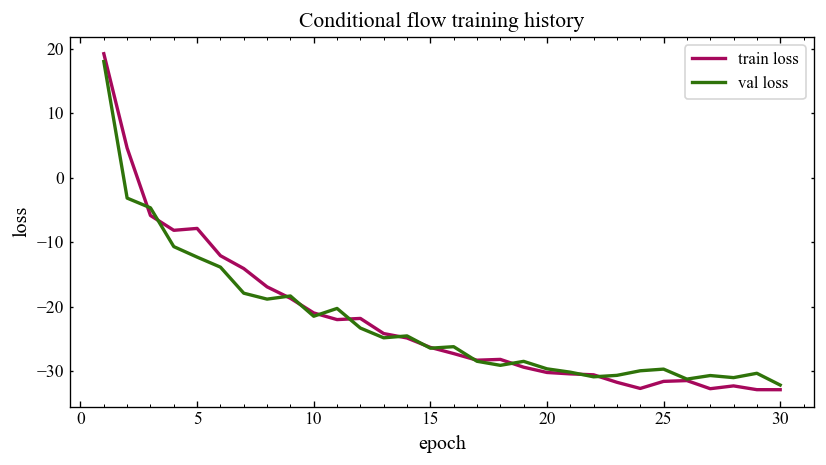

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train loss", color = line_colors["train"])
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val loss", color = line_colors["loss"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Conditional flow training history")
plt.legend()
plt.show()

In [24]:
def reconstruct_example_with_flow(
    model: ConditionalRealNVP,
    ex: Dict,
    n_samples: int = 128,
):
    """
    Draw posterior samples for the target-band gap using the trained flow.
    """

    model.eval()

    tokens = torch.tensor(
        ex["context_tokens"],
        dtype=torch.float32,
        device=device,
    )[None, ...]

    band_ids = torch.tensor(
        ex["band_ids"],
        dtype=torch.long,
        device=device,
    )[None, ...]

    baseline = torch.tensor(
        ex["baseline_std"],
        dtype=torch.float32,
        device=device,
    )[None, ...]

    with torch.no_grad():
        residual_samples = model.sample(
            n_samples=n_samples,
            tokens=tokens,
            band_ids=band_ids,
        )[0].cpu().numpy()

    y_samples_std = (
        baseline.cpu().numpy()[0][None, :]
        + residual_samples
    )

    y_samples = (
        float(ex["mu_local"])
        + float(ex["amp_local"]) * y_samples_std
    )

    return {
        "residual_samples_std": residual_samples,
        "y_samples_std": y_samples_std,
        "y_samples": y_samples,
    }

## Evaluation metrics

Reconstruction quality is evaluated using both accuracy and uncertainty-based metrics. The root mean squared error (RMSE) and mean absolute error (MAE) measure agreement between the posterior median reconstruction and the hidden target-band trajectory. Coverage68 measures the fraction of true values contained within the central $68\%$ predictive interval, while Width68 measures the average width of this interval.

Together, these metrics assess not only reconstruction accuracy but also whether the predictive uncertainty is appropriately calibrated.

In [25]:
def interval_metrics(
    y_true: np.ndarray,
    y_samples: np.ndarray,
):
    """
    Accuracy and posterior-interval metrics.
    """

    med = np.median(y_samples, axis=0)

    q16 = np.quantile(y_samples, 0.16, axis=0)
    q84 = np.quantile(y_samples, 0.84, axis=0)

    rmse = float(
        np.sqrt(
            np.mean((med - y_true) ** 2)
        )
    )

    mae = float(
        np.mean(
            np.abs(med - y_true)
        )
    )

    coverage68 = float(
        np.mean(
            (y_true >= q16)
            & (y_true <= q84)
        )
    )

    width68 = float(
        np.mean(q84 - q16)
    )

    corr = float(
        np.corrcoef(med, y_true)[0, 1]
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "coverage68": coverage68,
        "width68": width68,
        "corr": corr,
    }

## Example multiband reconstructions



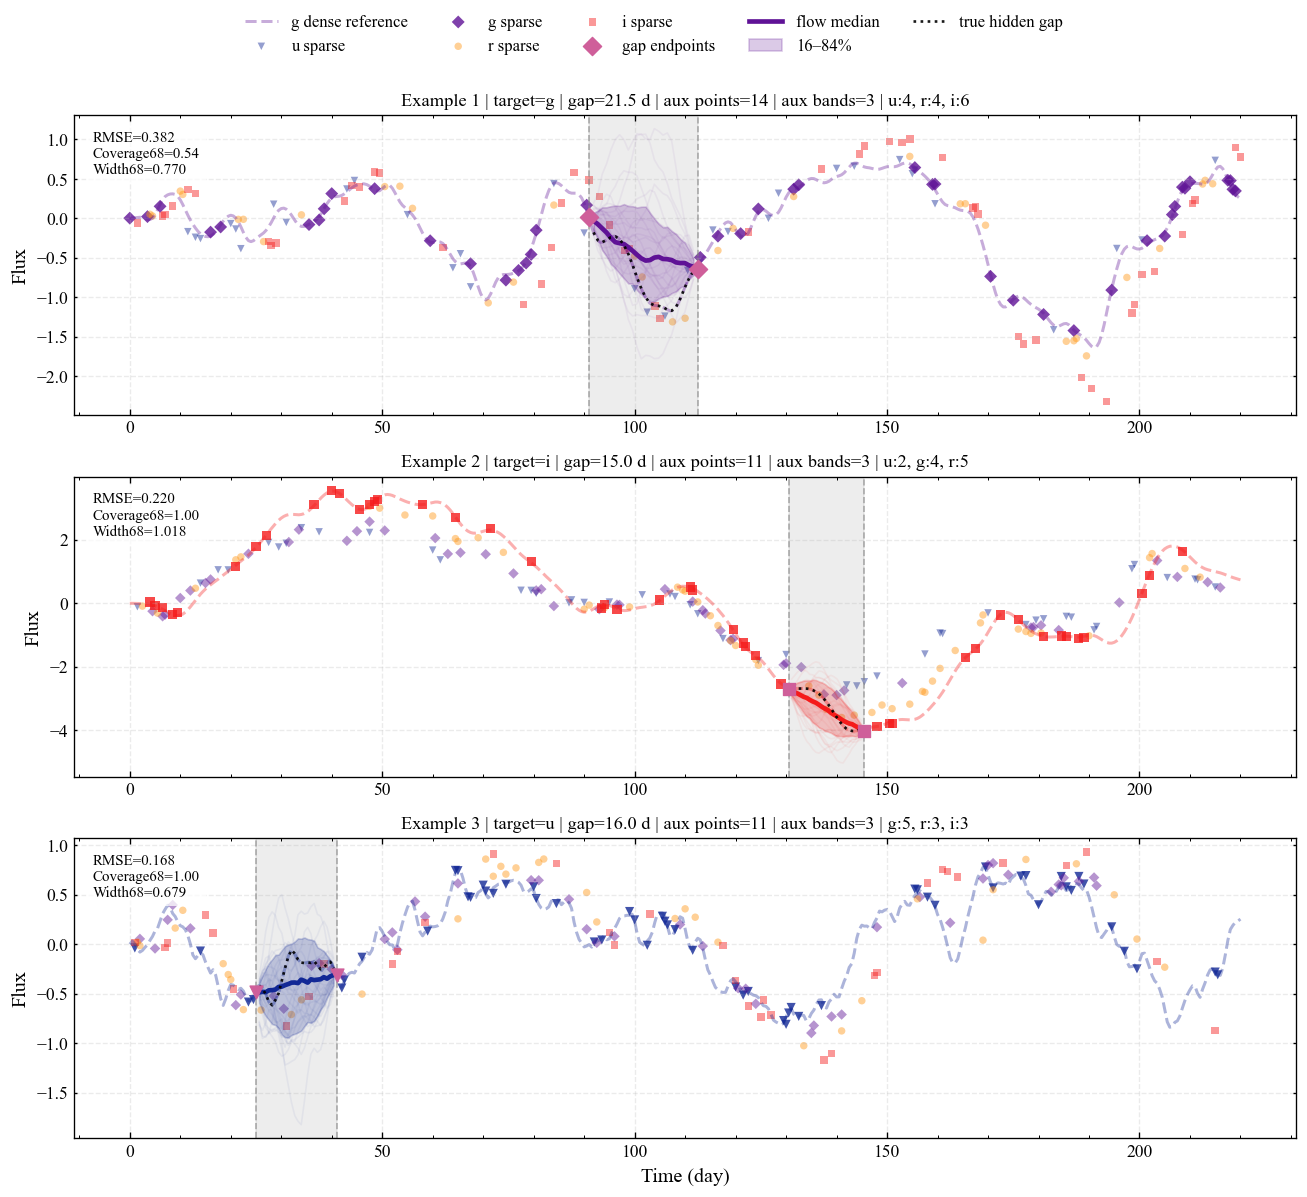

In [26]:
rng = np.random.default_rng(2024)

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 10),
    sharex=False,
)

for i, ax in enumerate(axes):

    ex = sample_supported_example(
        n_bands=4,
        K=24,
        n_side=6,
        target_band=None,
        rng=rng,
    )

    target_band = ex["target_band"]
    t_left = float(ex["t_left"])
    t_right = float(ex["t_right"])

    # Dense reference
    ax.plot(
        ex["dense"]["t_dense"],
        ex["dense"]["bands"][target_band]["y_dense"],
        color=band_colors[target_band],
        lw=1.8,
        alpha=0.35,
        ls="--",
        label=f"{target_band} dense reference",
    )

    # sparse observations
    for band, obs in ex["sparse_demo"].items():

        is_target = band == target_band

        ax.scatter(
            obs["t_obs"],
            obs["y_obs"],
            s=30 if is_target else 20,
            color=band_colors[band],
            marker=band_markers[band],
            alpha=0.8 if is_target else 0.45,
            label=f"{band} sparse",
            edgecolor="none",
        )

    # Gap shading
    ax.axvspan(
        t_left,
        t_right,
        color="grey",
        alpha=0.14,
    )

    ax.axvline(
        t_left,
        color="grey",
        ls="--",
        lw=1,
        alpha=0.6,
    )

    ax.axvline(
        t_right,
        color="grey",
        ls="--",
        lw=1,
        alpha=0.6,
    )

    # Gap endpoints
    y_left = float(ex["target_sparse"]["y_obs"][ex["gap_left_idx"]])
    y_right = float(ex["target_sparse"]["y_obs"][ex["gap_right_idx"]])

    ax.scatter(
        [t_left, t_right],
        [y_left, y_right],
        s=60,
        color=band_colors["support"],
        marker=band_markers[target_band],
        #edgecolor="black",
        linewidth=0.8,
        zorder=10,
        label="gap endpoints",
    )


    # Flow reconstruction
    

    rec = reconstruct_example_with_flow(
        model,
        ex,
        n_samples=250,
    )

    med = np.median(rec["y_samples"], axis=0)
    q16 = np.quantile(rec["y_samples"], 0.16, axis=0)
    q84 = np.quantile(rec["y_samples"], 0.84, axis=0)

    # posterior samples
    for j in range(min(25, rec["y_samples"].shape[0])):
        ax.plot(
            ex["t_gap"],
            rec["y_samples"][j],
            color=band_colors[target_band],
            alpha=0.05,
            lw=1,
        )

    # median prediction
    ax.plot(
        ex["t_gap"],
        med,
        color=band_colors[target_band],
        lw=2.8,
        label="flow median",
        zorder=8,
    )

    # uncertainty band
    ax.fill_between(
        ex["t_gap"],
        q16,
        q84,
        color=band_colors[target_band],
        alpha=0.22,
        label="16–84%",
        zorder=5,
    )

    # true hidden gap values
    ax.plot(
        ex["t_gap"],
        ex["y_true_gap"],
        color="black",
        lw=1.6,
        alpha=0.9,
        ls=":",
        label="true hidden gap",
        zorder=9,
    )

    # metrics
    metrics = interval_metrics(
        ex["y_true_gap"],
        rec["y_samples"],
    )

    ax.text(
        0.015,
        0.95,
        (
            f"RMSE={metrics['rmse']:.3f}\n"
            f"Coverage68={metrics['coverage68']:.2f}\n"
            f"Width68={metrics['width68']:.3f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none",
        ),
    )

    aux_per_band = ", ".join(
        [f"{b}:{c}" for b, c in ex["aux_points_per_band"].items()]
    )

    ax.set_title(
        f"Example {i+1} | target={target_band} | "
        f"gap={float(ex['dt_gap']):.1f} d | "
        f"aux points={ex['aux_points_in_gap']} | "
        f"aux bands={ex['aux_bands_with_point']} | "
        f"{aux_per_band}",
        fontsize=11,
    )

    ax.set_ylabel("Flux")
    ax.grid(alpha=0.25, linestyle="--")

axes[-1].set_xlabel("Time (day)")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=5,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Reconstructions from the flow model are shown for different target bands and gap configurations. The shaded region marks the target-band interval, the dashed curve shows the dense reference, and the black dotted curve shows the true hidden trajectory inside the gap. The flow median and central $68\%$ interval summarize the model posterior.

These examples show that the current model produces plausible smooth gap reconstructions, but it does not consistently recover the hidden target-band trajectory. In these cases, the posterior median is biased toward a simple bridge-like interpolation between the gap endpoints, even when auxiliary-band observations are available inside the missing interval. The uncertainty intervals are sometimes wide enough to cover the true curve, but the median prediction often misses sharper local structure.

This qualitative behavior is consistent with the population-level results: the model captures some broad temporal variability but does not yet make strong or reliable use of auxiliary support. The examples therefore motivate improvements to the context encoder and conditioning mechanism, especially architectures that preserve the timing and band identity of individual auxiliary observations rather than compressing each band into coarse summary features.

## 10. Checking how different support regimes affect ONE example gap

In [27]:
def evaluate_same_gap_support_sweep(
    model,
    ex_base: Dict,
    support_grid: List[Tuple[int, int]],
    rng: np.random.Generator | None = None,
    n_samples: int = 200,
) -> pd.DataFrame:

    if rng is None:
        rng = np.random.default_rng()

    rows = []

    for n_points, n_bands in support_grid:

        try:
            ex = rebuild_example_with_controlled_support(
                ex_base,
                n_aux_points=n_points,
                n_aux_bands=n_bands,
                rng=rng,
            )

            rec = reconstruct_example_with_flow(
                model,
                ex,
                n_samples=n_samples,
            )

            m = interval_metrics(
                ex["y_true_gap"],
                rec["y_samples"],
            )

            rows.append({
                "aux_points": int(ex["aux_points_in_gap"]),
                "aux_bands": int(ex["aux_bands_with_point"]),
                "requested_aux_points": int(n_points),
                "requested_aux_bands": int(n_bands),
                "gap_width": float(ex["dt_gap"]),
                **m,
            })

        except ValueError:
            continue

    return pd.DataFrame(rows)

In [ ]:
support_grid = [
    (0, 0),
    (1, 1),
    (2, 1),
    (3, 2),
    (4, 2),
    (6, 3),
]

rng = np.random.default_rng(123)

base_ex = sample_supported_example(
    n_bands=4,
    K=residual_dim,
    n_side=6,
    target_band="r",
    rng=rng,
)

ex_low = rebuild_example_with_controlled_support(
    base_ex,
    n_aux_points=0,
    n_aux_bands=0,
    rng=rng,
)

ex_high = rebuild_example_with_controlled_support(
    base_ex,
    n_aux_points=6,
    n_aux_bands=3,
    rng=rng,
)

print("LOW SUPPORT")
print(ex_low["aux_points_per_band"])
print(ex_low["context_tokens"])

print("\nHIGH SUPPORT")
print(ex_high["aux_points_per_band"])
print(ex_high["context_tokens"])

same_gap_df = evaluate_same_gap_support_sweep(
    model,
    base_ex,
    support_grid=support_grid,
    rng=rng,
    n_samples=200,
)

same_gap_df

LOW SUPPORT
{'u': 0, 'g': 0, 'i': 0}
[[-0.62437356  0.7986061  -0.7343418   0.63846886  0.15033157  0.6525157
  -0.34748426  0.09433962  0.5         0.5         0.          0.
   0.02273309  0.02382484  0.88144845]
 [-1.2643359   0.71638554  0.33777097  0.7574253   0.17075168  0.5204403
  -0.47955975  0.20754717  0.5         0.5         0.          0.
   0.06722779  0.04497292  0.8738524 ]
 [ 0.          0.996134    2.6214056   0.75126433  0.13484244  0.2515723
  -0.7484277   0.1509434   0.5         0.5         0.          0.
   0.13743688  0.05287907  1.1480416 ]
 [ 0.12590185  0.6883277   0.48333013  0.3666863   0.14854385  0.5566037
  -0.44339624  0.09433962  0.5         0.5         0.          0.
   0.22638379  0.08143235  1.2832466 ]]

HIGH SUPPORT
{'u': 3, 'g': 2, 'i': 1}
[[-0.50637174  0.88030106 -0.87407595  0.953892    0.15257896  0.6163522
  -0.38364786  0.1509434   0.4         0.4         3.          1.
   0.02273309  0.02382484  0.88144845]
 [-1.1370536   0.7340848   0.3647

,aux_points,aux_bands,requested_aux_points,requested_aux_bands,gap_width,rmse,mae,coverage68,width68,corr
0,0,0,0,0,26.5,0.343700,0.271843,0.291667,0.293784,0.601392
1,1,1,1,1,26.5,0.356230,0.279075,0.333333,0.352851,0.480509
2,2,1,2,1,26.5,0.357458,0.281040,0.375000,0.351105,0.480814
3,3,2,3,2,26.5,0.341258,0.268723,0.291667,0.234986,0.581931
4,4,2,4,2,26.5,0.367413,0.288612,0.291667,0.286229,0.416686
5,6,3,6,3,26.5,0.350772,0.277664,0.333333,0.283385,0.535749


## Checking for the whole population

In [29]:

def evaluate_validation_population(
    model,
    n_examples=400,
    n_samples=128,
    seed=1234,
):

    rng = np.random.default_rng(seed)

    rows = []

    for _ in range(n_examples):

        ex = sample_supported_example(
            n_bands=4,
            K=residual_dim,
            n_side=6,
            rng=rng,
        )

        rec = reconstruct_example_with_flow(
            model,
            ex,
            n_samples=n_samples,
        )

        m = interval_metrics(
            ex["y_true_gap"],
            rec["y_samples"],
        )

        rows.append({
            "target_band": ex["target_band"],
            "gap_width": float(ex["dt_gap"]),
            "aux_points": int(ex["aux_points_in_gap"]),
            "aux_bands": int(ex["aux_bands_with_point"]),
            **m,
        })

    return pd.DataFrame(rows)


population_df = evaluate_validation_population(
    model,
    n_examples=500,
    n_samples=128,
)

population_df.head()

,target_band,gap_width,aux_points,aux_bands,rmse,mae,coverage68,width68,corr
0,r,13.5,13,3,0.205234,0.154627,0.833333,0.621028,0.217833
1,i,10.0,9,3,0.037581,0.032053,1.000000,0.429672,0.991490
2,u,16.5,19,3,0.165863,0.122806,0.958333,0.677288,0.862129
3,u,35.0,37,3,0.190166,0.169209,1.000000,0.894887,-0.675106
4,g,18.0,13,3,0.226129,0.199931,0.791667,0.461551,0.167886


## Correlation analysis

Naturally, wider gaps contain a larger number of auxiliary points

            gap_width  aux_points
gap_width    1.000000    0.755472
aux_points   0.755472    1.000000


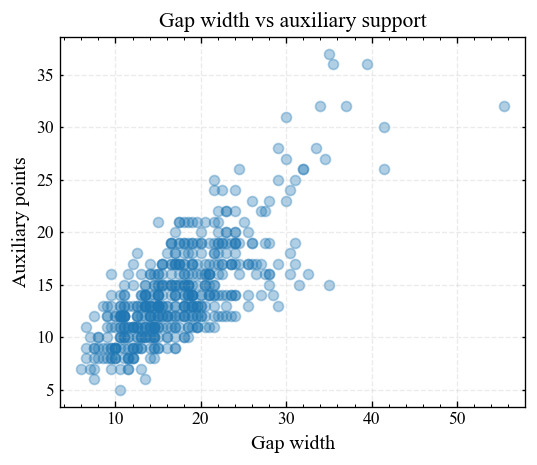

In [30]:
print(population_df[["gap_width", "aux_points"]].corr())

plt.figure(figsize=(5,4))

plt.scatter(
    population_df["gap_width"],
    population_df["aux_points"],
    alpha=0.35,
)

plt.xlabel("Gap width")
plt.ylabel("Auxiliary points")
plt.title("Gap width vs auxiliary support")

plt.grid(alpha=0.25)
plt.show()

In [31]:
population_df[["gap_width", "aux_points", "aux_bands", "rmse"]].corr()

,gap_width,aux_points,aux_bands,rmse
gap_width,1.000000,0.755472,0.026966,0.421507
aux_points,0.755472,1.000000,0.061834,0.273416
aux_bands,0.026966,0.061834,1.000000,0.009206
rmse,0.421507,0.273416,0.009206,1.000000



The correlation analysis shows a strong positive relationship between target-gap width and the number of auxiliary observations inside the gap, with

$$
\mathrm{corr}(\mathrm{gap\ width}, \mathrm{aux\ points}) \approx 0.76.
$$

This indicates that larger gaps naturally accumulate more auxiliary support due to their longer temporal extent. Gap width is also positively correlated with reconstruction error,

$$
\mathrm{corr}(\mathrm{gap\ width}, \mathrm{RMSE}) \approx 0.41,
$$

showing that wider gaps are intrinsically more difficult to reconstruct. Consequently, the positive correlation between auxiliary-point count and RMSE does not imply that additional support degrades performance. Instead, it reflects the fact that larger and more difficult interpolation problems naturally contain more auxiliary observations. In contrast, the number of contributing auxiliary bands shows little direct correlation with RMSE

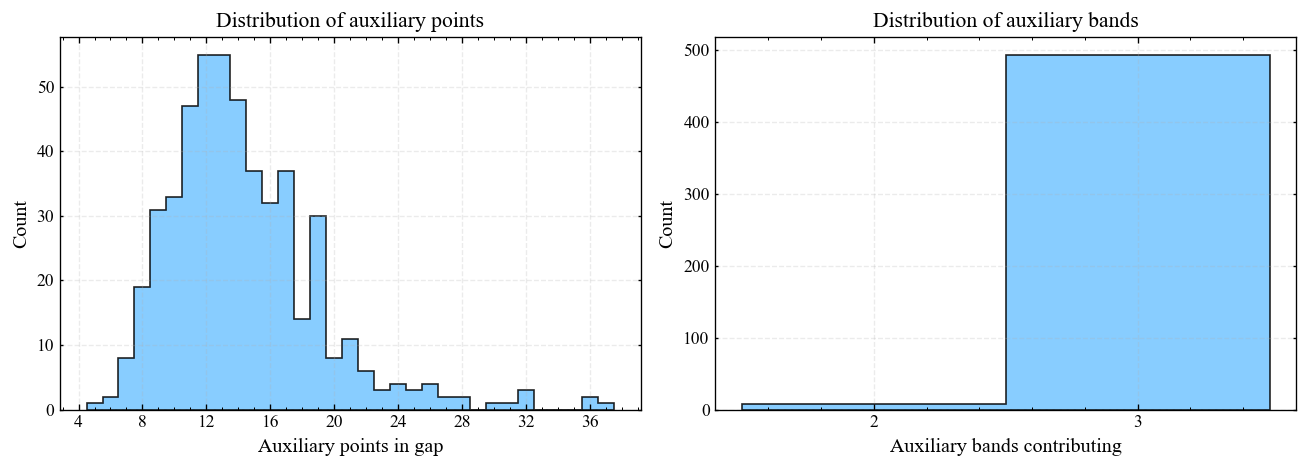

In [32]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4),
)


point_bins = np.arange(
    population_df["aux_points"].min() - 0.5,
    population_df["aux_points"].max() + 1.5,
    1,
)

axes[0].hist(
    population_df["aux_points"],
    bins=point_bins,
    color=line_colors["valid"],
    alpha=0.85,
    edgecolor="black", histtype = "stepfilled",
)

axes[0].set_xlabel("Auxiliary points in gap")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of auxiliary points")

axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].grid(alpha=0.25, linestyle="--")


band_bins = np.arange(
    population_df["aux_bands"].min() - 0.5,
    population_df["aux_bands"].max() + 1.5,
    1,
)

axes[1].hist(
    population_df["aux_bands"],
    bins=band_bins,
    color=line_colors["valid"],
    alpha=0.85, histtype = "stepfilled",
    edgecolor="black",
)

axes[1].set_xlabel("Auxiliary bands contributing")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of auxiliary bands")

axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].grid(alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

In [33]:

group_points = (
    population_df
    .groupby("aux_points")
    [["rmse", "coverage68", "width68", "corr"]]
    .agg(["mean", "std", "count"])
)

display(group_points)

rmse                 coverage68                   width68  \
                mean       std count       mean       std count      mean   
aux_points                                                                  
5           0.029320       NaN     1   1.000000       NaN     1  0.847342   
6           0.260293  0.026465     2   0.458333  0.058926     2  0.363116   
7           0.221752  0.070291     8   0.552083  0.294417     8  0.434985   
8           0.262802  0.168456    19   0.550439  0.385796    19  0.501097   
9           0.246881  0.122280    31   0.637097  0.303947    31  0.539783   
10          0.219379  0.116105    33   0.775253  0.234071    33  0.565966   
11          0.272805  0.137009    47   0.734043  0.270248    47  0.715103   
12          0.328848  0.208074    55   0.711364  0.274735    55  0.759497   
13          0.293800  0.230580    55   0.728030  0.285973    55  0.745214   
14          0.378241  0.230507    48   0.667535  0.267072    48  0.745864   
15          0.273788  0.174580    37   0.831081  0.211309    37  0.797549   
16          0.290846  0.160927    32   0.820312  0.213101    32  0.872717   
17          0.341516  0.195064    37   0.726351  0.277872    37  0.846739   
18          0.300165  0.169535    14   0.699405  0.269129    14  0.747028   
19          0.377393  0.217682    30   0.761111  0.256835    30  0.990831   
20          0.515684  0.270769     8   0.682292  0.277225     8  1.108278   
21          0.282476  0.145136    11   0.818182  0.235166    11  0.895741   
22          0.390934  0.312428     6   0.930556  0.170103     6  1.422450   
23          0.712076  0.512818     3   0.583333  0.363242     3  1.210202   
24          0.286811  0.135065     4   0.843750  0.216172     4  0.876204   
25          0.429857  0.078253     3   0.805556  0.173472     3  1.449603   
26          0.584249  0.437555     4   0.583333  0.278471     4  1.006560   
27          0.317623  0.147331     2   0.916667  0.117851     2  1.165947   
28          0.682058  0.274002     2   0.625000  0.294628     2  1.261307   
30          0.376664       NaN     1   0.750000       NaN     1  0.996186   
31          0.373708       NaN     1   1.000000       NaN     1  1.433561   
32          0.764284  0.037475     3   0.791667  0.291667     3  2.282831   
36          0.543724  0.199833     2   0.604167  0.088388     2  1.078478   
37          0.190166       NaN     1   1.000000       NaN     1  0.894887   

                                corr                  
                 std count      mean       std count  
aux_points                                            
5                NaN     1  0.997182       NaN     1  
6           0.058253     2  0.208858  0.997452     2  
7           0.144279     8  0.804466  0.184521     8  
8           0.246503    19  0.549977  0.389145    19  
9           0.198878    31  0.658092  0.382594    31  
10          0.232575    33  0.495062  0.597096    33  
11          0.301173    47  0.607912  0.473846    47  
12          0.343699    55  0.680495  0.319974    55  
13          0.396931    55  0.575418  0.497267    55  
14          0.232678    48  0.552253  0.442975    48  
15          0.309672    37  0.498491  0.533503    37  
16          0.324555    32  0.667741  0.347134    32  
17          0.300749    37  0.596770  0.376242    37  
18          0.165027    14  0.485166  0.420174    14  
19          0.403226    30  0.466863  0.516080    30  
20          0.465109     8  0.716758  0.239131     8  
21          0.282585    11  0.631183  0.418517    11  
22          0.533218     6  0.773197  0.159087     6  
23          0.313017     3  0.770907  0.286208     3  
24          0.152948     4  0.557659  0.357481     4  
25          0.692576     3  0.440956  0.237961     3  
26          0.535294     4  0.670728  0.271814     4  
27          0.729734     2  0.081519  0.265426     2  
28          0.167547     2  0.355305  0.046009     2  
30               NaN     1  0.749294       NaN     1  
31         

In [34]:

group_bands = (
    population_df
    .groupby("aux_bands")
    [["rmse", "coverage68", "width68", "corr"]]
    .agg(["mean", "std", "count"])
)

display(group_bands)

rmse                 coverage68                   width68  \
               mean       std count       mean       std count      mean   
aux_bands                                                                  
2          0.299882  0.094340     7   0.785714  0.162141     7  0.763835   
3          0.315902  0.205841   493   0.726504  0.273673   493  0.782365   

                               corr                  
                std count      mean       std count  
aux_bands                                            
2          0.293049     7  0.531006  0.578583     7  
3          0.378843   493  0.583186  0.440852   493

In [36]:
metric_pairs = [
    ("rmse", "RMSE"),
    ("coverage68", "Coverage68"),
    ("width68", "Width68"),
    ("corr", "Correlation"),
]

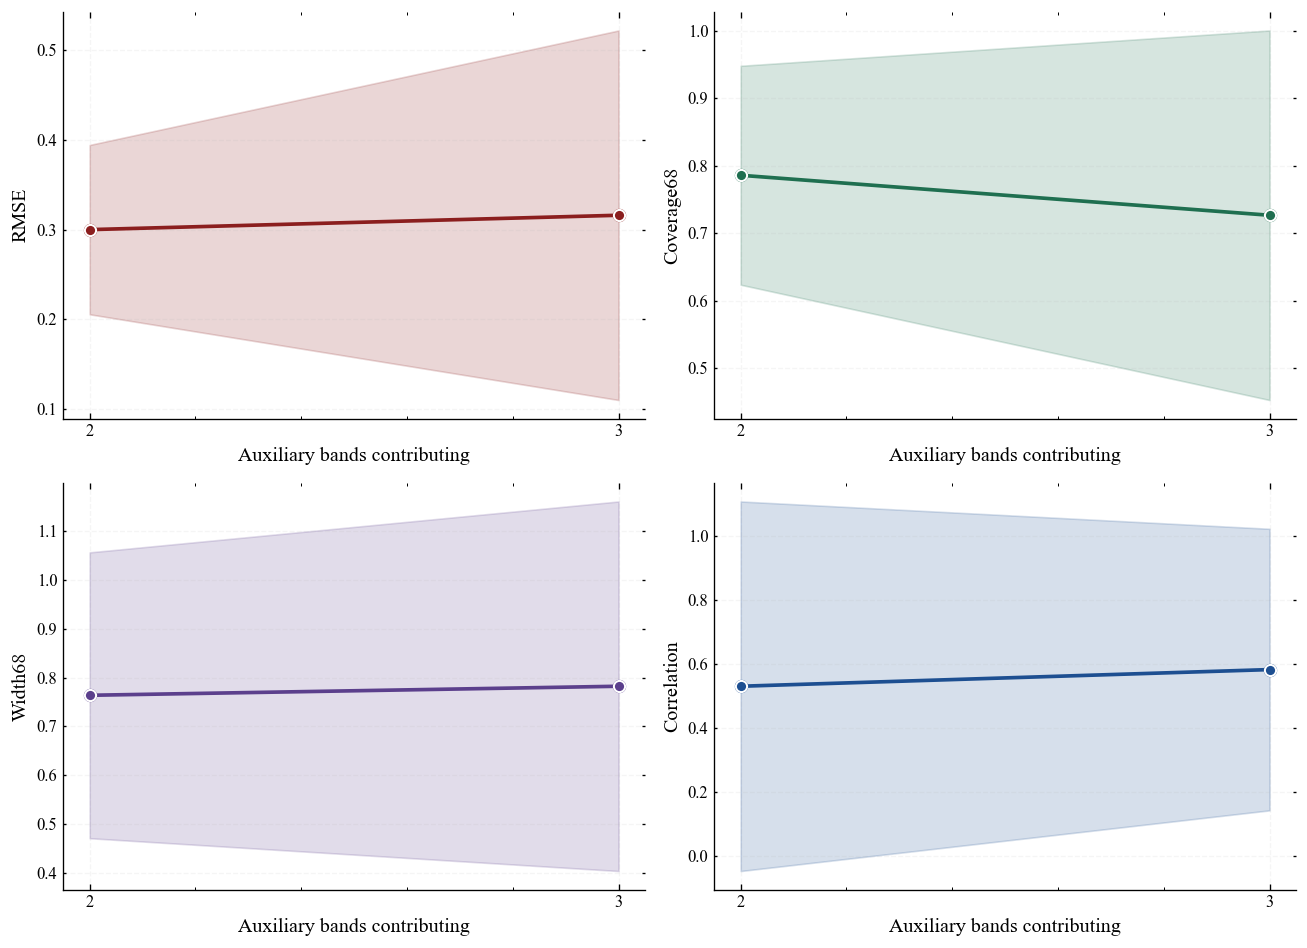

In [37]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
)

metric_colors = {
    "rmse": "#8b1e1e",
    "coverage68": "#1f6f50",
    "width68": "#5b3f8c",
    "corr": "#1d4f91",
}

for ax, (metric, label) in zip(axes.flat, metric_pairs):

    grouped = (
        population_df
        .groupby("aux_bands")[metric]
    )

    means = grouped.mean()
    stds = grouped.std()

    x = means.index.values.astype(float)
    y = means.values
    yerr = stds.values

    color = metric_colors[metric]

    # confidence region
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        color=color,
        alpha=0.18,
    )

    # trend line
    ax.plot(
        x,
        y,
        marker="o",
        ms=7,
        lw=2.2,
        color=color,
    )

    # point markers
    ax.scatter(
        x,
        y,
        s=45,
        color=color,
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )

    ax.set_xlabel("Auxiliary bands contributing")
    ax.set_ylabel(label)

    # cleaner axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        alpha=0.12,
        linestyle="--",
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=10,
    )

    ax.set_xticks(x)

plt.tight_layout()
plt.show()

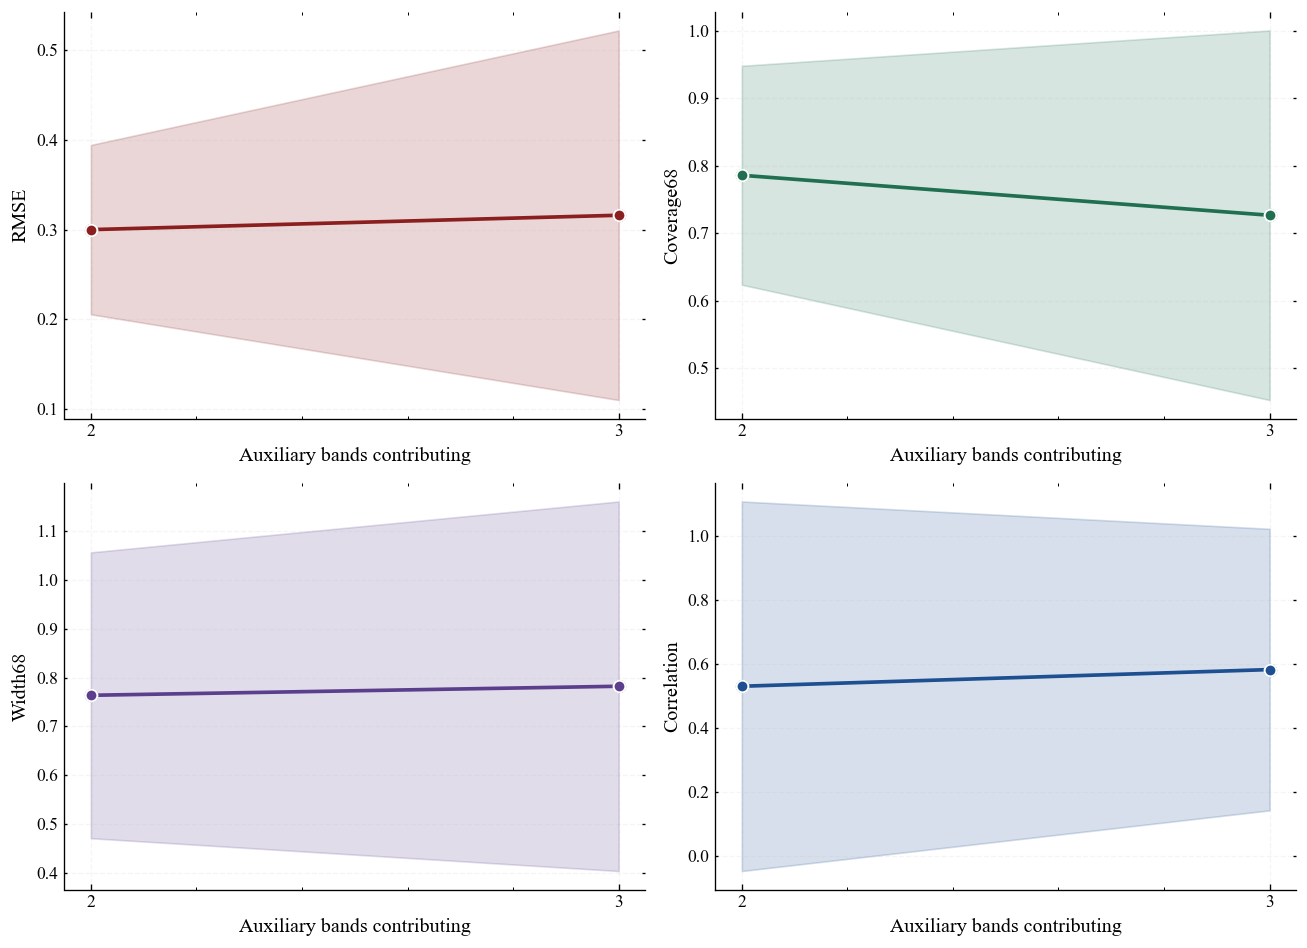

In [39]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
)

metric_colors = {
    "rmse": "#8b1e1e",
    "coverage68": "#1f6f50",
    "width68": "#5b3f8c",
    "corr": "#1d4f91",
}

for ax, (metric, label) in zip(axes.flat, metric_pairs):

    grouped = (
        population_df
        .groupby("aux_bands")[metric]
    )

    means = grouped.mean()
    stds = grouped.std()

    x = means.index.values.astype(int)
    y = means.values
    yerr = stds.values

    color = metric_colors[metric]

    # uncertainty region
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        color=color,
        alpha=0.18,
    )

    # trend line
    ax.plot(
        x,
        y,
        marker="o",
        ms=7,
        lw=2.2,
        color=color,
    )

    # point markers
    ax.scatter(
        x,
        y,
        s=50,
        color=color,
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )

    ax.set_xlabel("Auxiliary bands contributing")
    ax.set_ylabel(label)

    # integer ticks only
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x])

    # cleaner styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        alpha=0.12,
        linestyle="--",
    )

plt.tight_layout()
plt.show()

## Current conclusions

Reconstruction quality is not determined solely by the raw number of auxiliary observations inside the target gap. Instead, the analysis shows that auxiliary support is strongly coupled to gap geometry.

A strong positive correlation was found between gap width and the number of auxiliary observations inside the gap, indicating that larger gaps naturally accumulate more multiband support. At the same time, larger gaps are intrinsically more difficult to reconstruct and therefore produce higher reconstruction error. As a consequence, raw auxiliary-point counts alone do not yield a clean monotonic improvement in RMSE.

The results suggest that the geometric structure of auxiliary support is more informative than the total support count. In particular, ongoing analysis show that reconstruction quality improves when auxiliary observations occur closer to the target-gap midpoint, indicating that local temporal overlap could be more important than simply increasing the number of observations or contributing bands.

Overall, the analysis indicates that reconstruction performance depends on a combination of gap width, temporal support geometry, cadence density, and multiband overlap structure rather than on auxiliary support counts alone.

## Future work??

Future work will focus on disentangling auxiliary support from gap geometry by maybe introducing **normalized** support metrics and explicitly modeling temporal support structure. Additional analysis couldl investigate the role of nearest auxiliary distance and band-specific temporal offsets. Architecturally, the V01 and V02 of the model will explore attention-based or set-based context encoders that preserve inter-band relationships more explicitly than the current pooled representation. 